# Decision Tree Early-Warning Model: Day 30

This notebook develops and evaluates a Decision Tree classifier using the Day 30 early-warning dataset created for the SEAID Framework.

The model uses only information available on or before Day 30 of the course. Its performance will be compared with the Day 30 Logistic Regression baseline to determine whether a nonlinear model improves early prediction of student outcomes.

## Notebook Objectives

1. Load and inspect the Day 30 modeling dataset.
2. Prepare the predictor variables and target variable.
3. Create consistent training and testing datasets.
4. Train a baseline Decision Tree classifier.
5. Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, a classification report, a confusion matrix, and an ROC curve.
6. Examine feature importance.
7. Save the trained model and evaluation outputs.
8. Compare the Decision Tree results with the Day 30 Logistic Regression baseline.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Day 30 Modeling Dataset

This section defines the project file paths, loads the Day 30 early-warning dataset, and verifies that the data were imported correctly.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

base = Path("/content/drive/MyDrive")

for item in sorted(base.iterdir()):
    print(item)

/content/drive/MyDrive/AI_Midterm
/content/drive/MyDrive/Bi Cheat Sheet exam 2 Copy.docx
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Copy of Lab8_Sequence_RNN_SV_completed.ipynb
/content/drive/MyDrive/Copy of Module 2:  Research Design Methodology DRAFT.gdoc
/content/drive/MyDrive/Copy of Untitled document.docx
/content/drive/MyDrive/Copy of user_jobs_anonymized.csv
/content/drive/MyDrive/DSBA 6156 9 17 25.gdoc
/content/drive/MyDrive/DSBA 6165 LAB 6 HANDNOTE.gsheet
/content/drive/MyDrive/DSBA 6165 Lab Handnotes_6.23.26.gsheet
/content/drive/MyDrive/DSBA 6201 Midterm Study Guide.gdoc
/content/drive/MyDrive/DSBA 6211 1 13, 1 20 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 1 27 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 10 Lecture Notes (1).gdoc
/content/drive/MyDrive/DSBA 6211 2 10 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 17 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 3 Zoom Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 Com

In [5]:
from pathlib import Path

matches = list(Path("/content/drive/MyDrive").rglob("final_modeling_dataset_day30.csv"))

print("Matches found:", len(matches))

for match in matches:
    print(match)

Matches found: 1
/content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv


In [6]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_PATH.exists())

Dataset exists: True


## Prepare the Predictor Variables and Target

The binary target variable is `target_success`, where successful and unsuccessful course outcomes are represented numerically. The original `final_result` column is excluded from the predictors because it directly contains the course outcome and would create target leakage.

Student and course identifiers are also removed because they identify records rather than represent meaningful predictive features.

In [8]:
modeling_data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", modeling_data.shape)

display(modeling_data.head())

Dataset loaded successfully.
Dataset shape: (32593, 77)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


In [10]:
print("Dataset columns:")
for column in modeling_data.columns:
    print(column)

Dataset columns:
code_module
code_presentation
id_student
gender
num_of_prev_attempts
studied_credits
disability
final_result
target_success
total_clicks
average_clicks_per_record
median_clicks_per_record
maximum_clicks_in_record
vle_records
active_days
unique_vle_activities
first_activity_day
last_activity_day
clicks_per_active_day
activity_span_days
clicks_per_vle_activity
log_total_clicks
assessments_completed
average_score
median_score
minimum_score
maximum_score
score_std
average_weight
total_weight_completed
first_submission_day
last_submission_day
banked_assessments
assessment_span_days
score_range
weighted_average_score
score_improvement
assessment_intensity
log_assessments_completed
date_registration
registered_before_start
registered_after_start
days_registered_before_start
region_East Midlands Region
region_Ireland
region_London Region
region_North Region
region_North Western Region
region_Scotland
region_South East Region
region_South Region
region_South West Region
region_

In [11]:
TARGET = "target_success"

columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

X = modeling_data.drop(columns=columns_to_drop)
y = modeling_data[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts().sort_index())

print("\nTarget proportions:")
display(
    y.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Predictor matrix shape: (32593, 74)
Target vector shape: (32593,)

Target distribution:


,count
target_success,
0,17208
1,15385



Target proportions:


,proportion
target_success,
0,0.528
1,0.472


In [12]:
print("Target values:", sorted(y.unique()))
print("Missing target values:", y.isna().sum())
print("Duplicate predictor columns:", X.columns.duplicated().sum())

Target values: [np.int64(0), np.int64(1)]
Missing target values: 0
Duplicate predictor columns: 0


## Create Training and Testing Sets

The dataset is divided into training and testing subsets using an 80/20 split. Stratified sampling is used to preserve the proportion of successful and unsuccessful students in both datasets, ensuring a fair evaluation of model performance.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)
print()

print("Training target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print()

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training predictor shape: (26074, 74)
Testing predictor shape: (6519, 74)

Training target distribution:


,proportion
target_success,
0,0.528
1,0.472



Testing target distribution:


,proportion
target_success,
0,0.528
1,0.472


## Create the Preprocessing Pipeline

The Decision Tree classifier does not require feature scaling because tree-based algorithms are not affected by differences in variable magnitudes. Therefore, the preprocessing pipeline focuses on handling missing values while preserving the original scale of the predictor variables.

Numeric features are imputed using the median, while categorical features (if present) are imputed using the most frequent category and one-hot encoded.

In [14]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 72
Categorical features: 2


In [15]:
print(categorical_features)

['code_module', 'code_presentation']


## Train the Decision Tree Classifier

This section combines the preprocessing steps with a Decision Tree classifier and trains the model using the Day 30 training dataset.

In [17]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [21]:
y_pred = decision_tree_pipeline.predict(X_test)

y_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate Model Performance

This section evaluates the Decision Tree classifier using accuracy, precision, recall, F1 score, and ROC-AUC. These metrics allow direct comparison with the Day 30 Logistic Regression baseline.

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)

display(metrics_df)

,Metric,Value
0,Accuracy,0.687222
1,Precision,0.670836
2,Recall,0.662333
3,F1 Score,0.666558
4,ROC-AUC,0.685902


## Classification Report

The classification report provides class-specific precision, recall, and F1 scores for unsuccessful and successful students.

In [23]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.6872
Precision: 0.6708
Recall:    0.6623
F1 Score:  0.6666
ROC-AUC:   0.6859


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.70      0.71      0.71      3442
  Successful       0.67      0.66      0.67      3077

    accuracy                           0.69      6519
   macro avg       0.69      0.69      0.69      6519
weighted avg       0.69      0.69      0.69      6519



In [25]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
Unsuccessful,0.701523,0.709471,0.705475,3442.000000
Successful,0.670836,0.662333,0.666558,3077.000000
accuracy,0.687222,0.687222,0.687222,0.687222
macro avg,0.686179,0.685902,0.686016,6519.000000
weighted avg,0.687038,0.687222,0.687106,6519.000000


## Classification Report Interpretation

The Decision Tree demonstrated moderately balanced performance across unsuccessful and successful students.

For unsuccessful students, the model achieved a precision of **70.2%**, a recall of **70.9%**, and an F1 score of **70.5%**. This indicates that the model correctly identified most unsuccessful students, while approximately 29% of that group was misclassified.

For successful students, the model achieved a precision of **67.1%**, a recall of **66.2%**, and an F1 score of **66.7%**. These results show that the model was somewhat less effective at identifying successful students than unsuccessful students.

The macro-average F1 score of **68.6%** and weighted-average F1 score of **68.7%** suggest that performance was reasonably balanced across the two outcome classes. However, the Decision Tree performed below the Day 30 Logistic Regression baseline on all major evaluation metrics.

Overall, the classification report indicates that a single untuned Decision Tree captures some meaningful nonlinear patterns in the Day 30 data, but it does not generalize as effectively as Logistic Regression. This result supports evaluating ensemble tree-based methods, such as Random Forest and XGBoost, which may reduce overfitting and improve predictive performance.

## Confusion Matrix

The confusion matrix compares the model's predicted outcomes with the actual student outcomes and shows the number of correct and incorrect classifications for each class.

In [26]:
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion matrix:")
print(confusion_matrix_values)

Confusion matrix:
[[2442 1000]
 [1039 2038]]


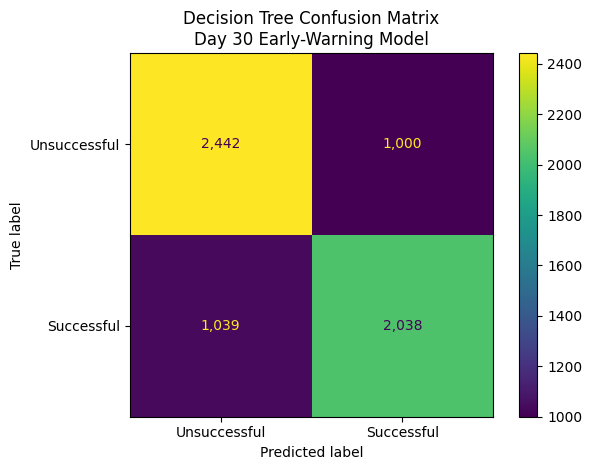

In [27]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(
    values_format=",d"
)

plt.title(
    "Decision Tree Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The confusion matrix summarizes the Decision Tree classifier's predictions by comparing the predicted outcomes with the actual student outcomes.

- **2,442 unsuccessful students** were correctly classified as unsuccessful.
- **2,038 successful students** were correctly classified as successful.
- **1,000 unsuccessful students** were incorrectly predicted to be successful.
- **1,039 successful students** were incorrectly predicted to be unsuccessful.

The Decision Tree correctly classified the majority of students in both outcome classes, but it produced a relatively balanced number of false-positive and false-negative predictions. Compared with the Day 30 Logistic Regression model, the Decision Tree generated more classification errors and demonstrated lower overall predictive performance.

Although the model identified meaningful patterns within the early-course data, the confusion matrix suggests that a single Decision Tree is more susceptible to prediction errors than the Logistic Regression baseline. These findings motivate the evaluation of ensemble tree-based methods, such as Random Forest and XGBoost, which often improve classification accuracy by combining the predictions of multiple decision trees.

## Receiver Operating Characteristic (ROC) Curve

The ROC curve evaluates the Decision Tree classifier's ability to distinguish between successful and unsuccessful students across all possible classification thresholds.

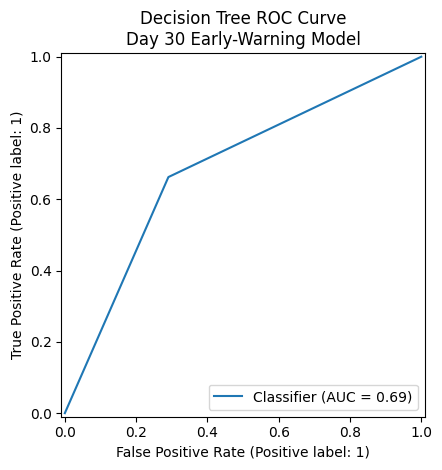

In [28]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Decision Tree ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Receiver Operating Characteristic (ROC) Curve Interpretation

The Decision Tree classifier achieved a **ROC-AUC of 0.6859**, indicating moderate discrimination between successful and unsuccessful students using information available during the first 30 days of the course.

Compared with the Day 30 Logistic Regression model (ROC-AUC = **0.8193**), the Decision Tree demonstrated substantially lower discriminative ability. This suggests that the linear logistic regression model generalized more effectively to unseen student data than a single, untuned decision tree.

Although the Decision Tree captured meaningful patterns within the early-warning dataset, its lower ROC-AUC indicates that it was less effective at distinguishing between the two outcome classes. This result highlights one of the primary limitations of individual decision trees and supports the evaluation of ensemble methods, such as Random Forest and XGBoost, which often provide improved predictive performance and greater robustness.